In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE


In [8]:
df = pd.read_csv("creditcard.csv")

In [9]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [11]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [12]:
class_counts = df["Class"].value_counts()

print("Legitimate transactions:", class_counts[0])
print("Fraudulent transactions:", class_counts[1])

fraud_percentage = (class_counts[1] / len(df)) * 100

print(f"Fraudulent transactions: {fraud_percentage:.2f}%")

Legitimate transactions: 284315
Fraudulent transactions: 492
Fraudulent transactions: 0.17%


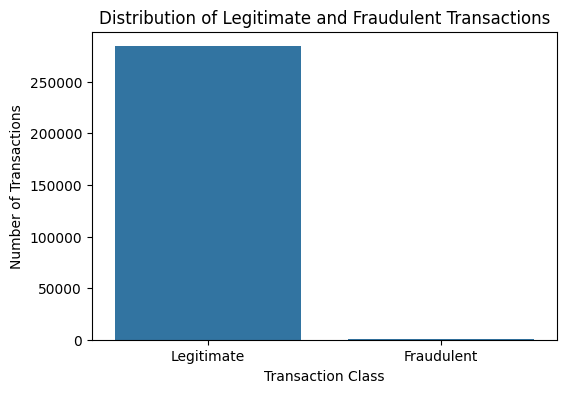

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Class", data=df)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])

plt.show()

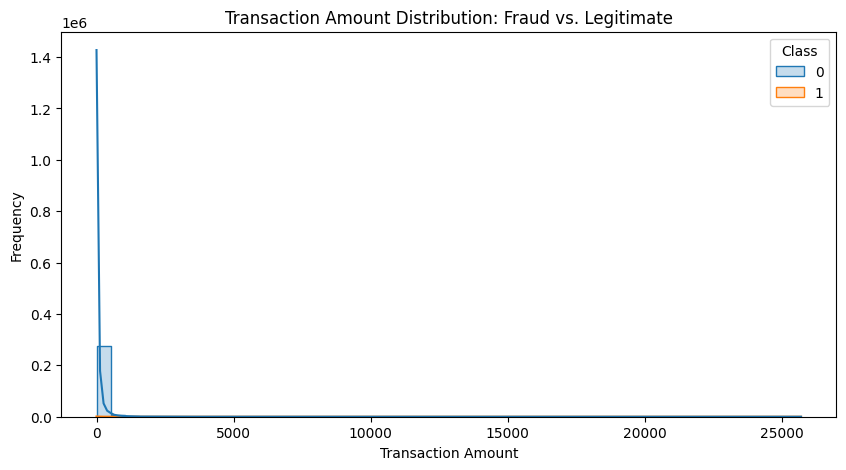

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    kde=True,
    element="step"
)

plt.title("Transaction Amount Distribution: Fraud vs. Legitimate")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

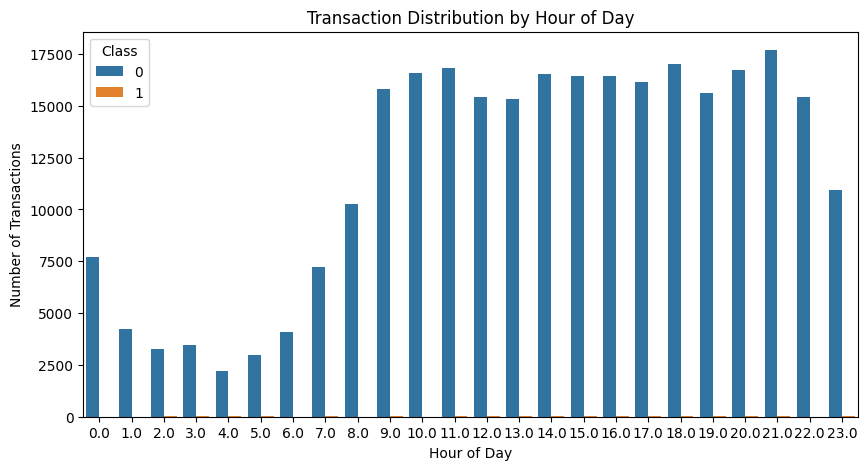

In [15]:
df["Hour"] = (df["Time"] // 3600) % 24

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Hour",
    hue="Class"
)

plt.title("Transaction Distribution by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

Why Accuracy Is Misleading in Fraud Detection

In this dataset, fraudulent transactions account for only about 0.17% of all transactions, while legitimate transactions account for about 99.83%. Because the dataset is highly imbalanced, accuracy alone is not a reliable evaluation metric.

For example, a model that predicts every transaction as legitimate could achieve approximately 99.83% accuracy, while detecting none of the fraudulent transactions. Such a model would be practically useless for fraud detection.

Therefore, we use Precision, Recall, F1-Score, and AUC-ROC to evaluate the models. These metrics provide a better understanding of how well the model identifies fraudulent transactions and controls false alarms.

Recall is particularly important when missing a fraudulent transaction is costly, while Precision becomes important when investigating false fraud alerts is costly.


In [16]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nFraud cases in training set:", y_train.sum())
print("Fraud cases in testing set:", y_test.sum())

Training set: (227845, 31)
Testing set: (56962, 31)

Fraud cases in training set: 394
Fraud cases in testing set: 98


In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature scaling completed!
Training data shape: (227845, 31)
Testing data shape: (56962, 31)


In [18]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [19]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_smote, y_train_smote)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [20]:
y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results")
print("-" * 35)

print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
-----------------------------------
Precision: 0.054945054945054944
Recall: 0.9183673469387755
F1-Score: 0.10368663594470046
AUC-ROC: 0.9729761593720212

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.54     56962
weighted avg       1.00      0.97      0.98     56962



In [21]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [22]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest Results")
print("-" * 35)

print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
-----------------------------------
Precision: 0.8404255319148937
Recall: 0.8061224489795918
F1-Score: 0.8229166666666666
AUC-ROC: 0.962243695663409

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.81      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



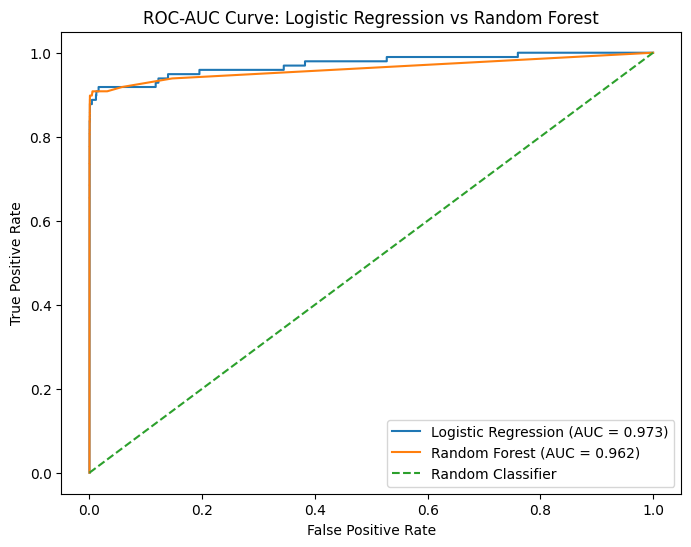

In [23]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC-AUC Curve: Logistic Regression vs Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

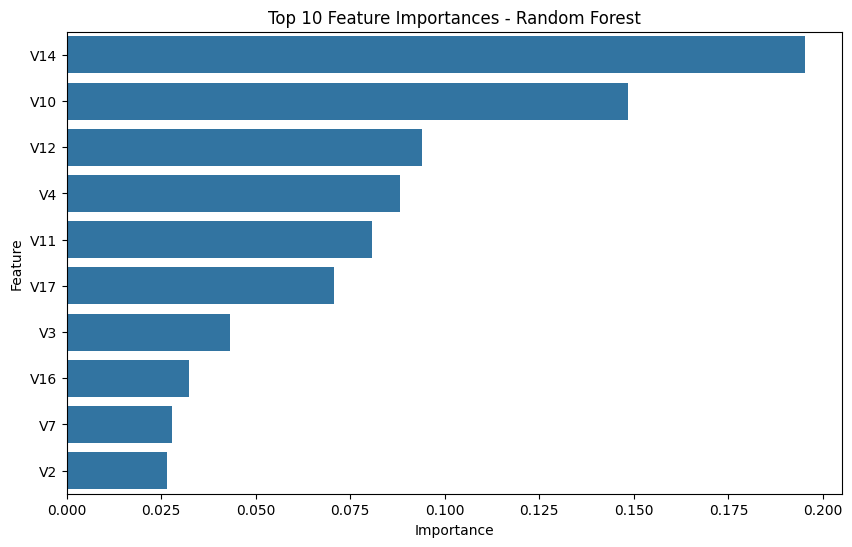

In [24]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=feature_importance.head(10),
    y=feature_importance.head(10).index
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Recall vs. Precision in Fraud Detection

Recall is particularly important in fraud detection because it measures the proportion of actual fraudulent transactions that the model successfully identifies. A low recall means that many fraudulent transactions are missed.

However, precision is also important because it measures how many transactions predicted as fraudulent are actually fraudulent. Low precision results in many false alerts, which can increase the workload for fraud investigation teams.

Therefore, the choice depends on the business objective. If missing a fraudulent transaction is more costly than investigating a false alert, higher recall should be prioritized. If excessive false alerts are costly, higher precision may be preferred.

In this project, Logistic Regression achieved higher recall (91.84%), while Random Forest achieved much higher precision (84.04%) and F1-score (82.29%). This demonstrates the trade-off between detecting more fraud and reducing false alerts.

## Scalability: Handling 1 Million Transactions per Hour

For a system processing 1 million transactions per hour, the fraud detection model needs to provide fast predictions and handle a large volume of data efficiently.

The trained model can be deployed as a real-time fraud detection service that processes transactions as they arrive. A scalable cloud-based infrastructure, distributed processing, and efficient feature engineering can help handle the high transaction volume.

For large-scale systems, the model can be optimized using techniques such as batch processing, parallel processing, model optimization, and efficient data pipelines. A monitoring system should also be used to track model performance and detect changes in fraud patterns over time.

Therefore, the model can be scaled to handle 1 million transactions per hour by combining an efficient machine learning model with scalable infrastructure and real-time data processing.

In [25]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "AUC-ROC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

,Model,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.054945,0.918367,0.103687,0.972976
1,Random Forest,0.840426,0.806122,0.822917,0.962244


## Conclusion

This project developed a machine learning pipeline for detecting fraudulent credit card transactions in a highly imbalanced dataset. The dataset contained 284,807 transactions, of which only 492 (0.17%) were fraudulent.

SMOTE was applied to the training data to address the severe class imbalance. Logistic Regression and Random Forest models were then trained and evaluated using Precision, Recall, F1-Score, and AUC-ROC rather than relying only on accuracy.

Logistic Regression achieved a high recall of 91.84%, meaning it detected most fraudulent transactions, but its precision was low at 5.49%. Random Forest achieved a much higher precision of 84.04% and an F1-score of 82.29%, while maintaining a recall of 80.61%.

Overall, the results demonstrate the importance of balancing fraud detection with false-positive control. The choice of model and evaluation metric should depend on the cost of missed fraud versus false alerts in a real-world financial system.